In [1]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

In [2]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        # "rad_uhi_20241029_125028_1",
        # "rad_uhi_20241029_125028_2",
        # "rad_uhi_20241029_125028_3",
        # "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_5
  rad_uhi_20241029_125028_5: Using GRIDDED format (T=1948, S=968)
✅ Combined shapes: X/Y/Z (1948, 968), RGB (1948, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_125028_5...
✅ Combined shapes: X/Y/Z (1948, 968), RGB (1948, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_125028_5...
✅ Loaded full cube: (1948, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 1948 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundari

In [3]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[5.04040241e+00, 0.00000000e+00, 4.36450100e+00, ...,
         1.13190031e-02, 0.00000000e+00, 0.00000000e+00],
        [4.37972307e+00, 0.00000000e+00, 2.08433890e+00, ...,
         6.54789526e-03, 1.71770191e+00, 0.00000000e+00],
        [5.08758736e+00, 0.00000000e+00, 2.89873815e+00, ...,
         4.65853786e+00, 1.06280921e-02, 0.00000000e+00],
        ...,
        [4.16363668e+00, 0.00000000e+00, 3.56821418e+00, ...,
         8.65765285e+00, 0.00000000e+00, 0.00000000e+00],
        [4.49345970e+00, 0.00000000e+00, 6.43933201e+00, ...,
         0.00000000e+00, 6.79716587e+00, 1.00000000e+00],
        [1.25041723e+00, 0.00000000e+00, 7.89473653e-01, ...,
         1.14331772e+02, 6.91796513e-03, 0.00000000e+00]],

       [[0.00000000e+00, 2.39771342e+00, 0.00000000e+00, ...,
         0.00000000e+00, 8.75879824e-02, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.92308545e+00],
        [0.00000000e+00, 

💡 Interactive mode: Click on the plot to display coordinates


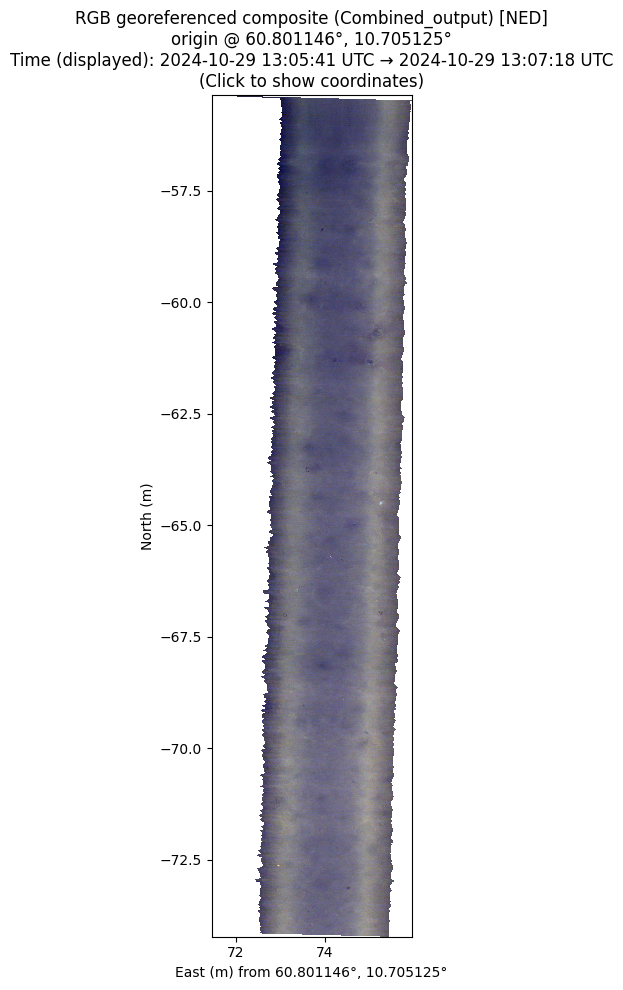

In [4]:
cube.plot_georef(
    use_corrected=False,
    coordinate_system="NED",
    # track_start=config.UHI_TRACK_RANGE_5[0],
    # track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
)

In [5]:
%matplotlib inline

💡 Interactive mode: Click on the plot to display coordinates


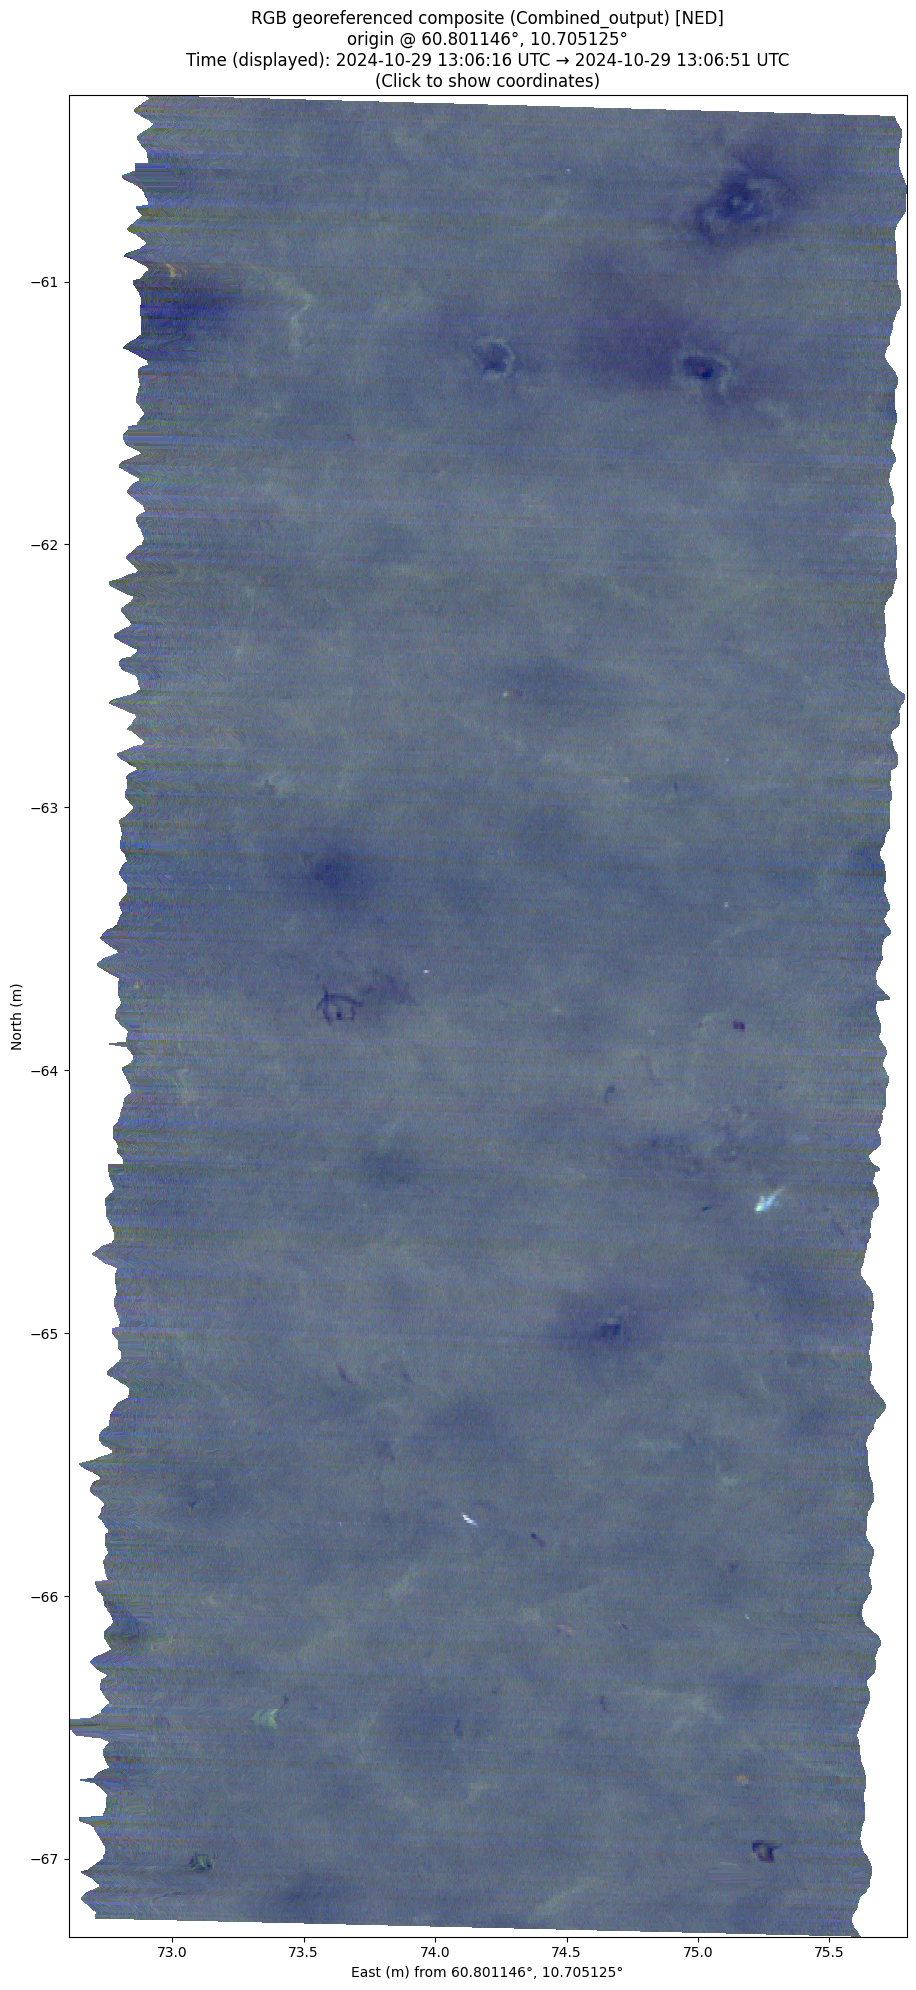

In [6]:
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=700,
    track_end=1400,
    figsize=(60, 20),
)

💡 Interactive mode: Click on the plot to display coordinates


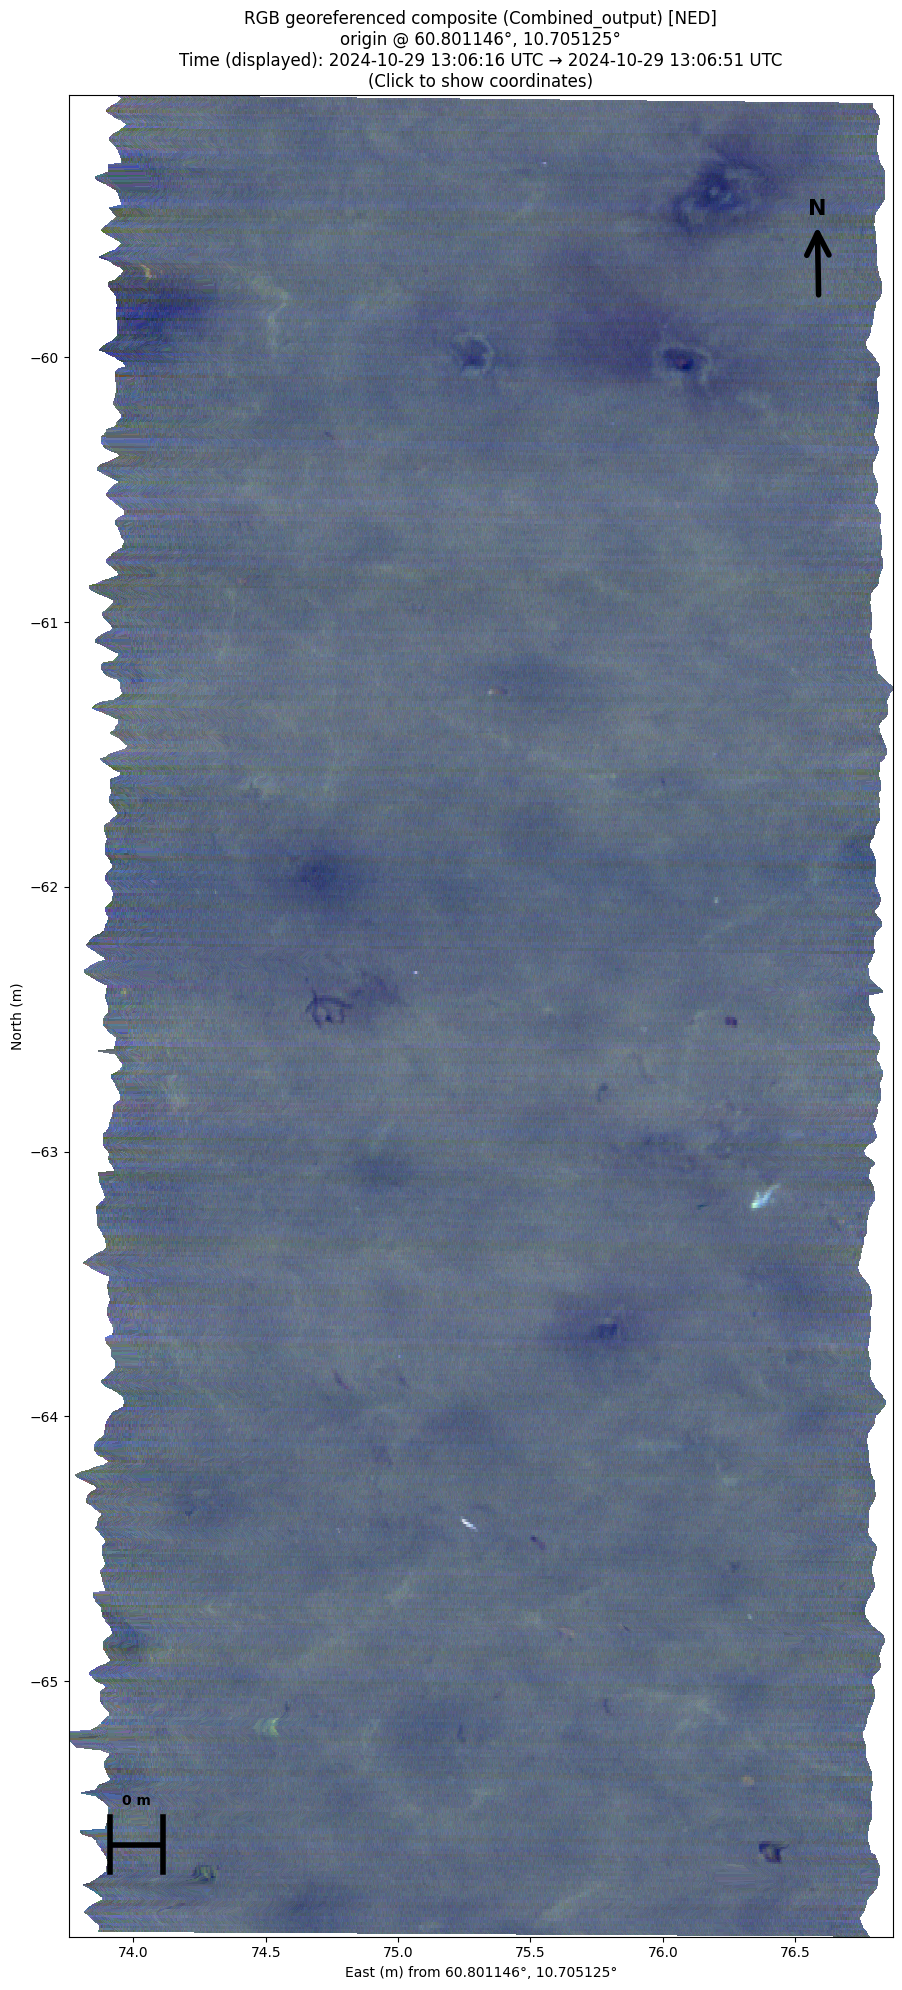

In [7]:
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=700,
    track_end=1400,
    figsize=(60, 20),
    rotation_deg=1,  # Rotation angle in degrees
    add_scale_bar=True,  # Enable scale bar
    scale_bar_position="lower left",  # Position
    scale_bar_color="black",  # Color
    scale_bar_fontsize=10,  # Font size
    add_north_arrow=True,  # Enable north arrow
    north_arrow_position="upper right",  # Position
    north_arrow_size=0.08,  # Size relative to plot
    north_arrow_color="black",  # Color
)

In [ ]:
# DEBUG: Check coordinate ranges to understand scale bar issue
import numpy as np

# Get the georef data directly from cube
X_ecef = cube.X_ecef
Y_ecef = cube.Y_ecef
Z_ecef = cube.Z_ecef

# Check if using NED - access config directly (not Specim sub-attribute)
lat0, lon0, h0 = config.LAT0, config.LON0, config.H0

# Sample some points (every 10th track, every 10th pixel)
track_start, track_end = 700, 1400
if track_end > X_ecef.shape[0]:
    track_end = X_ecef.shape[0]

sample_x = X_ecef[track_start:track_end:10, ::10].flatten()
sample_y = Y_ecef[track_start:track_end:10, ::10].flatten()
sample_z = Z_ecef[track_start:track_end:10, ::10].flatten()

# Remove NaN values
mask = np.isfinite(sample_x) & np.isfinite(sample_y) & np.isfinite(sample_z)
sample_x = sample_x[mask]
sample_y = sample_y[mask]
sample_z = sample_z[mask]

# Convert to NED
import pymap3d as pm

ned_points = [
    pm.ecef2ned(x, y, z, lat0, lon0, h0)
    for x, y, z in zip(sample_x, sample_y, sample_z)
]
ned_n = [p[0] for p in ned_points]
ned_e = [p[1] for p in ned_points]

print(f"Origin: LAT0={lat0}, LON0={lon0}, H0={h0}")
print(f"ECEF ranges (sampled):")
print(f"  X: {np.nanmin(sample_x):.2f} to {np.nanmax(sample_x):.2f} m")
print(f"  Y: {np.nanmin(sample_y):.2f} to {np.nanmax(sample_y):.2f} m")
print(f"  Z: {np.nanmin(sample_z):.2f} to {np.nanmax(sample_z):.2f} m")
print(f"\nNED ranges (sampled):")
print(
    f"  North: {np.min(ned_n):.2f} to {np.max(ned_n):.2f} m (range: {np.max(ned_n)-np.min(ned_n):.2f} m)"
)
print(
    f"  East: {np.min(ned_e):.2f} to {np.max(ned_e):.2f} m (range: {np.max(ned_e)-np.min(ned_e):.2f} m)"
)
print(f"\n15% of East range = {(np.max(ned_e)-np.min(ned_e)) * 0.15:.2f} m")

Origin: LAT0=60.801146, LON0=10.705125, H0=0.0
ECEF ranges (sampled):
  X: 3065185.09 to 3065191.67 m
  Y: 579530.95 to 579534.82 m
  Z: 5544437.90 to 5544441.14 m

NED ranges (sampled):
  North: -67.30 to -60.38 m (range: 6.92 m)
  East: 72.63 to 75.79 m (range: 3.17 m)

15% of East range = 0.48 m


💡 Interactive mode: Click on the plot to display coordinates


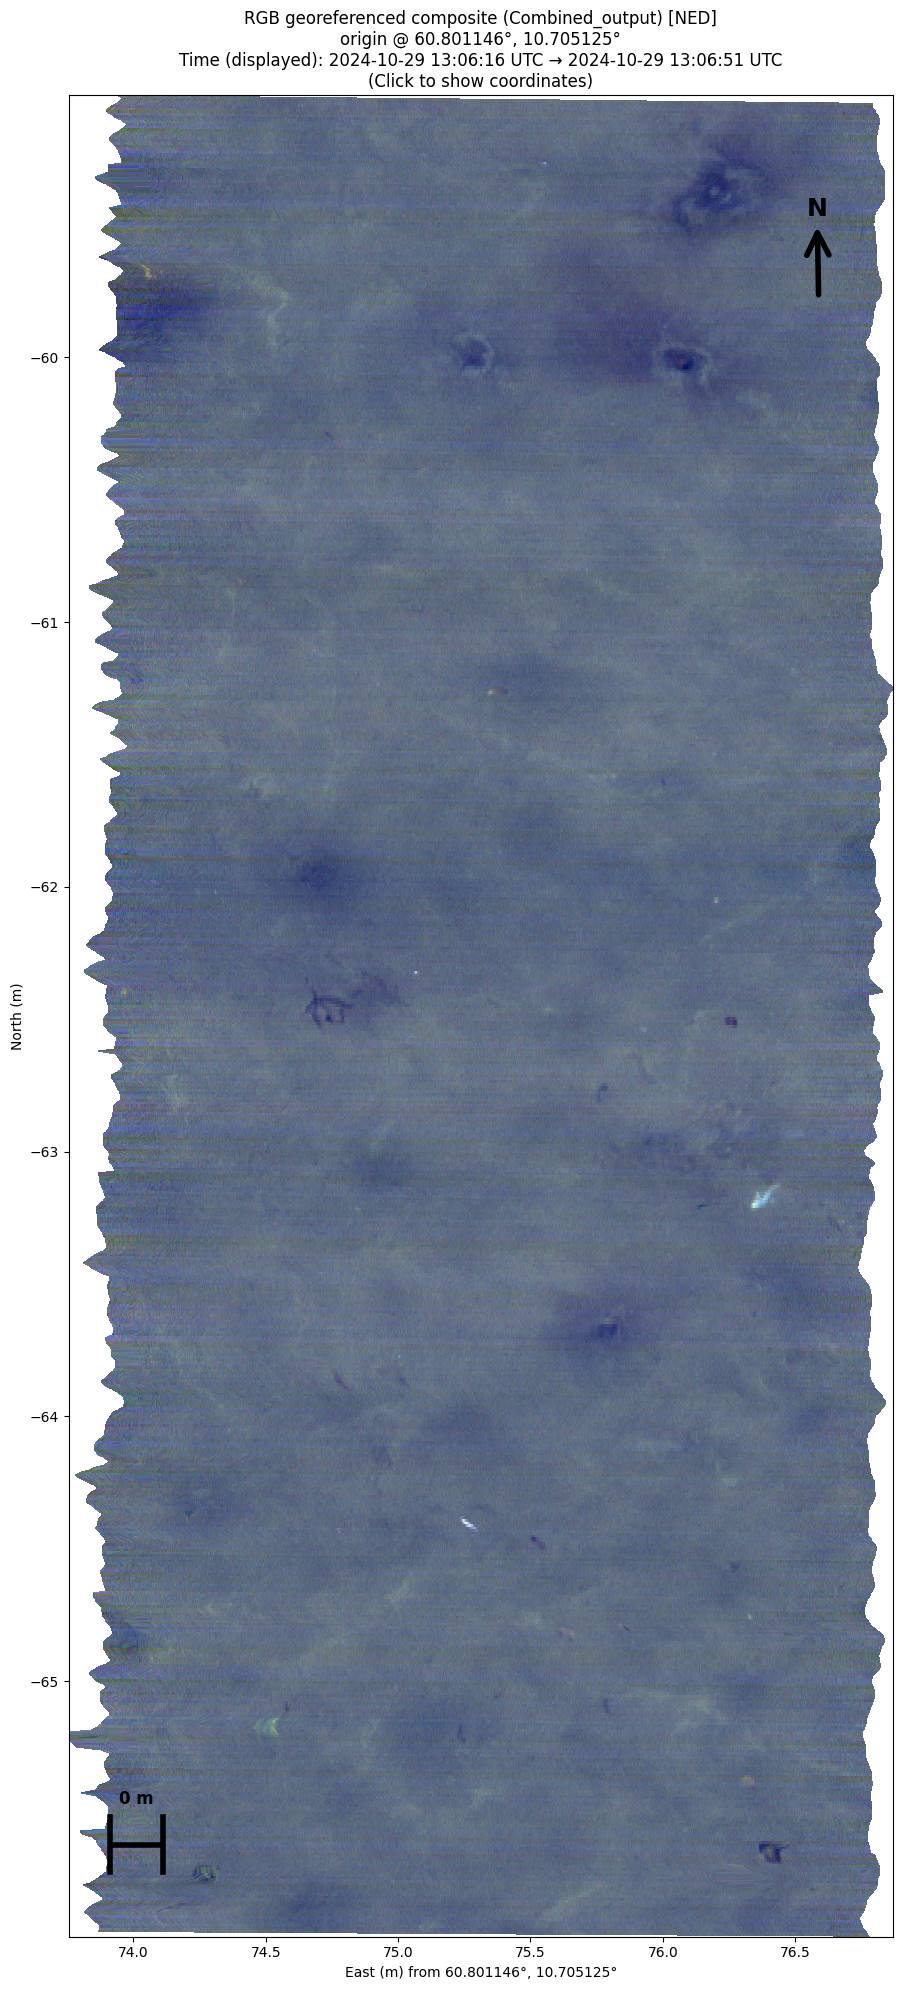

In [14]:
# Reload and test with debug output
importlib.reload(georef)
from utils.gref_pipeline.georef import *

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=700,
    track_end=1400,
    figsize=(60, 20),
    rotation_deg=1,
    add_scale_bar=True,
    scale_bar_position="lower left",
    scale_bar_color="black",
    scale_bar_fontsize=12,
    add_north_arrow=True,
    north_arrow_position="upper right",
    north_arrow_size=0.08,
    north_arrow_color="black",
    quiet=False,  # Enable debug output
)